# Unsupervised Representation Learning with Deep Convolutional GANs (DCGAN)

Replication of Radford, Metz and Chintala (2015), *Unsupervised Representation Learning with
Deep Convolutional Generative Adversarial Networks*, ICLR 2016.

DCGAN stabilizes GAN training with a set of architectural guidelines: an all-convolutional
generator and discriminator, strided and fractionally-strided convolutions instead of
pooling, batch normalization in both networks, ReLU/Tanh in the generator and LeakyReLU in
the discriminator. We implement these guidelines and train on MNIST, reproducing the result
that the convolutional architecture produces clean, coherent digit samples.

In [1]:
import torch, torch.nn as nn
import torchvision as tv, torchvision.transforms as T
import matplotlib.pyplot as plt
torch.manual_seed(0)
ZDIM = 100

In [2]:
tf = T.Compose([T.Resize(32), T.ToTensor(), T.Normalize((0.5,), (0.5,))])   # 32x32 in [-1,1]
train = tv.datasets.MNIST("../data", train=True, download=True, transform=tf)
train_dl = torch.utils.data.DataLoader(train, batch_size=128, shuffle=True, drop_last=True)
print("train", len(train))

train 60000


In [3]:
# Fractionally-strided conv generator: z -> 4x4 -> 8x8 -> 16x16 -> 32x32.
class G(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(ZDIM, 256, 4, 1, 0, bias=False), nn.BatchNorm2d(256), nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),  nn.BatchNorm2d(128), nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),   nn.BatchNorm2d(64),  nn.ReLU(True),
            nn.ConvTranspose2d(64, 1, 4, 2, 1, bias=False),     nn.Tanh())
    def forward(self, z): return self.net(z.view(-1, ZDIM, 1, 1))

# Strided conv discriminator with LeakyReLU and batchnorm.
class D(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 64, 4, 2, 1, bias=False), nn.LeakyReLU(0.2, True),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False), nn.BatchNorm2d(128), nn.LeakyReLU(0.2, True),
            nn.Conv2d(128, 256, 4, 2, 1, bias=False), nn.BatchNorm2d(256), nn.LeakyReLU(0.2, True),
            nn.Conv2d(256, 1, 4, 1, 0, bias=False), nn.Sigmoid())
    def forward(self, x): return self.net(x).view(-1, 1)

gen, disc = G(), D()
print("G params", sum(p.numel() for p in gen.parameters()), "| D params", sum(p.numel() for p in disc.parameters()))

G params 1066880 | D params 661248


In [4]:
bce = nn.BCELoss()
optG = torch.optim.Adam(gen.parameters(),  lr=2e-4, betas=(0.5, 0.999))
optD = torch.optim.Adam(disc.parameters(), lr=2e-4, betas=(0.5, 0.999))
fixed = torch.randn(64, ZDIM)
EPOCHS = 10
for ep in range(EPOCHS):
    for x, _ in train_dl:
        bs = x.size(0)
        real, fake = torch.ones(bs, 1), torch.zeros(bs, 1)
        z = torch.randn(bs, ZDIM); g = gen(z)
        lossD = bce(disc(x), real) + bce(disc(g.detach()), fake)
        optD.zero_grad(); lossD.backward(); optD.step()
        lossG = bce(disc(g), real)
        optG.zero_grad(); lossG.backward(); optG.step()
    print(f"epoch {ep+1:2d}: lossD={lossD.item():.3f} lossG={lossG.item():.3f}")

epoch  1: lossD=0.382 lossG=2.510


epoch  2: lossD=0.418 lossG=1.935


epoch  3: lossD=0.394 lossG=4.145


epoch  4: lossD=0.228 lossG=2.382


epoch  5: lossD=0.469 lossG=2.218


epoch  6: lossD=0.576 lossG=0.683


epoch  7: lossD=0.081 lossG=4.066


epoch  8: lossD=3.686 lossG=1.197


epoch  9: lossD=0.059 lossG=5.124


epoch 10: lossD=0.498 lossG=3.115


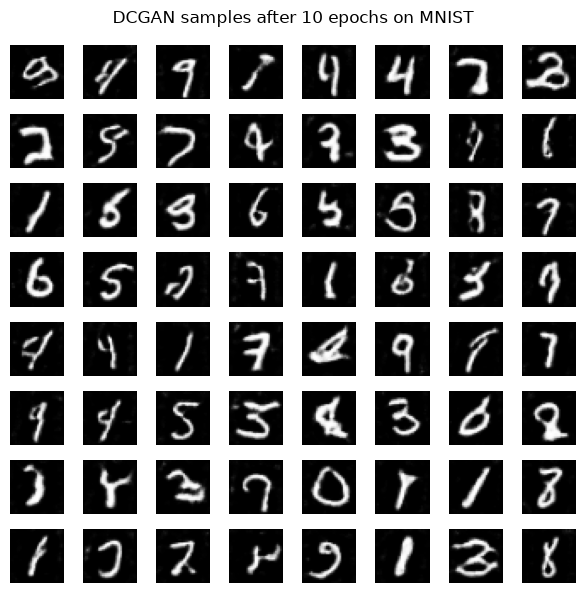

In [5]:
gen.eval()
with torch.no_grad():
    samples = gen(fixed).view(-1, 32, 32)
fig, ax = plt.subplots(8, 8, figsize=(6, 6))
for i, a in enumerate(ax.flat):
    a.imshow(samples[i], cmap="gray"); a.axis("off")
plt.suptitle(f"DCGAN samples after {EPOCHS} epochs on MNIST"); plt.tight_layout(); plt.show()